# PS-S6E01: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

**CatBoost** distinguishes itself with its native handling of categorical features, eliminating the need for extensive manual encoding (like One-Hot) often required by other gradient boosting libraries. It utilizes "Ordered Boosting" to combat target leakage and employs symmetric decision trees, which often leads to more robust generalization and faster inference speeds. This model is particularly effective when dealing with datasets containing a mix of numerical physiological markers and categorical demographic data without requiring complex preprocessing.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFECV
from catboost import CatBoostRegressor, Pool, EShapCalcType, EFeaturesSelectionAlgorithm

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering Strategy

We employ a custom `FeatureFactory` to inject domain-specific biases into the dataset. Tree-based models (like CatBoost) are excellent at finding split points but struggle with **interactions** (multiplying two features) and **spatial density** (clustering).

1.  **Binning (Discretization):**
    * **Why:** Continuous variables like `study_hours` often have non-linear "regimes". For example, the difference between 0 and 1 hour of study is massive, but the difference between 9 and 10 hours is negligible (diminishing returns).
    * **How:** We bin features into semantic categories (e.g., 'Core' vs. 'Burnout' study hours) to help the model treat these regimes differently.

2.  **Interaction Features:**
    * **Why:** A student who studies 10 hours but sleeps 2 hours performs differently than one who studies 10 and sleeps 8. A decision tree needs many splits to approximate this relationship `(Study / Sleep)`.
    * **How:** We explicitly create features like `restoration_index` (Sleep × Quality) and `study_to_sleep_ratio` to give the model these interaction surfaces directly.

3.  **K-Means Clustering:**
    * **Why:** Students likely fall into "archetypes" (e.g., "The grinder" = High Study/Low Sleep, "The natural" = Low Study/High Score).
    * **How:** We fit a K-Means clusterer on the raw behavioral data. The resulting `cluster_label` captures the multi-dimensional "shape" of a student's behavior in a single categorical feature.

In [5]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'binning',
    'log',
    'polynomials',
    'interactions',
    'clustering',
    'manual_formula',
    'cyclical'
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 39
   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc        7.910            98.800              no   
1   18   other  diploma        4.950            94.800             yes   
2   20  female     b.sc        4.680            92.600             yes   
3   19    male     b.sc        2.000            49.500             yes   
4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy 

In [7]:
def get_cat_features(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
        if c in df.columns:
            cat_cols.append(c)
    return list(dict.fromkeys(cat_cols))

cat_cols = get_cat_features(X)
print(f'Detected Categoricals: {cat_cols}')

print('Sanitizing categorical features...')

# Only cast true string categoricals; leave integer categoricals as ints
str_cats = [c for c in cat_cols if X[c].dtype == 'object' or str(X[c].dtype).startswith('category')]
if str_cats:
    X[str_cats] = X[str_cats].astype(str)
    X_test[str_cats] = X_test[str_cats].astype(str)

Detected Categoricals: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']
Sanitizing categorical features...


### Recursive Feature Elimination (RFE)

We optionally use **Recursive Feature Elimination** to slim down our feature set.

* **The Problem:** Adding many engineered features (ratios, polynomials, clusters) increases the chance of "overfitting"—where the model learns random noise in the training data rather than true signal.
* **The Solution:** RFE trains the model, checks which feature contributes the *least* to the prediction accuracy (using SHAP values or Feature Importance), drops it, and repeats.
* **The Result:** We find the smallest subset of features that maintains (or improves) the CV score, leading to a more robust model.

We use CatBoost's built-in `select_features` method with the **Recursive by SHAP** algorithm.
* **Mechanism:** The model is trained on all features. It calculates SHAP values (Shapley Additive Explanations) to measure the contribution of each feature to the prediction. The features with the lowest importance are removed, and the model is re-trained.
* **Goal:** Eliminate noise. Removing irrelevant features reduces the "curse of dimensionality" and often improves generalization.

RFE has been used experimentally, but has yet to improve scores.  It is preserved here for future experimentation.

In [8]:
n_jobs = 1 if USE_GPU else -1

if PERFORM_RFE:    
    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    
    # Define the model
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        loss_function='RMSE',
        eval_metric='RMSE',
        cat_features=cat_features,
        verbose=200,
        random_state=seed,
        early_stopping_rounds=50
    )
    
    # CREATE A SPLIT FOR FEATURE SELECTION
    # We need a validation set so CatBoost knows which features generalize well
    X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Create CatBoost Pools (required for feature selection)
    train_pool = Pool(X_fs_train, y_fs_train, cat_features=cat_features)
    val_pool = Pool(X_fs_val, y_fs_val, cat_features=cat_features)   
    
    # Run Native Feature Selection
    summary = model.select_features(
        train_pool,
        eval_set=val_pool,
        features_for_select=train_pool.get_feature_names(), # Pass the list of column names
        num_features_to_select=20,                          # How many features you want to keep
        steps=1,                                            # How many elimination rounds
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,                            # We just want the list, we'll retrain later
        plot=False
    )
    
    # View Selected Features
    # Save the selected features for the next step
    optimal_cols = summary['selected_features_names']
    print('Selected Features:', optimal_cols)
else:
    print('Using all columns as optimal features.')
    optimal_cols = X.columns
                            
print('\nOptimal Features:')
print(optimal_cols)

Using all columns as optimal features.

Optimal Features:
Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'class_attendance_class',
       'sleep_hours_class', 'study_hours_class', 'log_age', 'log_study_hours',
       'log_class_attendance', 'log_sleep_hours', 'age_sq', 'study_hours_sq',
       'class_attendance_sq', 'sleep_hours_sq', 'high_study',
       'study_to_sleep_ratio', 'attendance_to_study_ratio', 'total_engagement',
       'autodidact_ratio', 'weighted_study_hours', 'restoration_index',
       'study_att', 'effort_coaching_hours', 'effort_group_study_hours',
       'effort_mixed_hours', 'effort_online_videos_hours',
       'effort_self_study_hours', 'cluster_label', 'manual_formula',
       '_study_hours_sin', '_class_attendance_sin'],
      dtype='object')


### Optuna: Hyperparameter Tuning & Feature Selection

This section optimizes both the *data* (which features to keep) and the *model* (how it learns).

#### **Bayesian Optimization with Optuna**
Instead of a brute-force Grid Search, we use **Optuna**, which employs a Tree-structured Parzen Estimator (TPE).
* **How it works:** Optuna treats the hyperparameter search as a probabilistic problem. It looks at the history of previous trials to determine where the "best" hyperparameters likely reside in the search space.
* **Leakage-Free Objective Function:** Notice that inside the `objective` function, we perform **5-Fold Cross-Validation** and re-run the `FeatureFactory` for *every fold*. This is computationally expensive but necessary. It ensures that the hyperparameters are tuned on a setup that perfectly mimics the final training pipeline, preventing the optimizer from exploiting data leakage.
* **Pruning:** We use a `MedianPruner`. If a running trial is performing worse than the median of previous trials at a specific iteration, it is terminated early to save compute resources.

In [9]:
# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]

# Determine the cat_features for the new dataset
cat_features = get_cat_features(X_rfe)

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

print(f"Training shape: {X_rfe.shape}")
print(f"Categorical Features: {cat_features}")    
print(f"cols_to_keep: {cols_to_keep}")

def objective(trial):
    # Explicit garbage collection at start of trial
    gc.collect()

    # Define the Hyperparameter Search Space
    params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'iterations': 2000,                         # Cap lower for tuning structure, rely on early_stopping
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 100.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-4, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 64, 255),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),

        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'grow_policy': 'Depthwise',
        
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'allow_writing_files': False,        # Stop it from spamming drive with log folders
        'random_seed': seed,
        'verbose': False,
    }
    
    if params['task_type'] == 'CPU':
        params['rsm'] = trial.suggest_float('rsm', 0.5, 1.0)

    # Setup Cross-Validation Strategy
    # 5-Fold is standard. Shuffle is critical for regression to avoid sorting bias.
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    cv_scores = []
    
    # CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):
        X_train_fold, X_val_fold = X_rfe.iloc[train_idx], X_rfe.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Start with object/category
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Add discrete engineered columns explicitly
        for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
            if c in X_train_trans.columns:
                cat_cols.append(c)
        
        # De-dup while keeping order
        cat_cols = list(dict.fromkeys(cat_cols))
        
        # Only cast true string categoricals; leave integer categoricals as ints
        str_cats = [c for c in cat_cols if X_train_trans[c].dtype == 'object' or str(X_train_trans[c].dtype).startswith('category')]
        if str_cats:
            X_train_trans[str_cats] = X_train_trans[str_cats].astype(str)
            X_val_trans[str_cats]   = X_val_trans[str_cats].astype(str)
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols)
        val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)
        
        # Initialize and Fit
        model = CatBoostRegressor(**params)

        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        
        # Predict and Score
        preds = model.predict(val_pool)
        
        # Clip predictions to valid range (0-100) to improve RMSE
        preds = np.clip(preds, 0, 100)
        
        rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
        cv_scores.append(rmse)

    # Return the average RMSE across all folds
    return np.mean(cv_scores)

Training shape: (630000, 39)
Categorical Features: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']
cols_to_keep: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'log_age', 'log_study_hours', 'log_class_attendance', 'log_sleep_hours', 'age_sq', 'study_hours_sq', 'class_attendance_sq', 'sleep_hours_sq', 'high_study', 'study_to_sleep_ratio', 'attendance_to_study_ratio', 'total_engagement', 'autodidact_ratio', 'weighted_study_hours', 'restoration_index', 'study_att', 'effort_coaching_hours', 'effort_group_study_hours', 'effort_mixed_hours', 'effort_online_videos_hours', 'effort_self_study_hours', 'cluster_label', 'manual_formula', '_study_hours_sin', '_class_a

In [10]:
if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    print("Starting Optuna Optimization...")

    # Use MedianPruner to stop trials that are performing worse than the median of previous trials
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    
    study = optuna.create_study(
        study_name='cb_student_test_scores_optuna', 
        direction='minimize',
        pruner=pruner
    )
    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.05207922743912602,
        'depth': 6,
        'l2_leaf_reg': 1.2552172606269827,
        'random_strength': 0.0058444262890383885,
        'border_count': 244,
        'one_hot_max_size': 3,
        'min_data_in_leaf': 156,
        'leaf_estimation_iterations': 1,
        'subsample': 0.8953097403325773
    }

[I 2026-01-16 17:02:36,168] A new study created in memory with name: cb_student_test_scores_optuna


Starting Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-16 17:07:17,439] Trial 0 finished with value: 8.725023741320834 and parameters: {'learning_rate': 0.0648521835982644, 'depth': 4, 'l2_leaf_reg': 1.364139249141995, 'random_strength': 5.134315308666108, 'border_count': 233, 'one_hot_max_size': 10, 'min_data_in_leaf': 29, 'leaf_estimation_iterations': 4, 'subsample': 0.9662497649034703}. Best is trial 0 with value: 8.725023741320834.
[I 2026-01-16 17:13:29,897] Trial 1 finished with value: 8.727498494462047 and parameters: {'learning_rate': 0.05779965970033231, 'depth': 5, 'l2_leaf_reg': 8.462667779665155, 'random_strength': 0.0031447448163703187, 'border_count': 163, 'one_hot_max_size': 14, 'min_data_in_leaf': 27, 'leaf_estimation_iterations': 9, 'subsample': 0.9295408966341339}. Best is trial 0 with value: 8.725023741320834.
[I 2026-01-16 17:22:27,802] Trial 2 finished with value: 8.736846183459596 and parameters: {'learning_rate': 0.05643348578685095, 'depth': 4, 'l2_leaf_reg': 78.60642468982077, 'random_strength': 0.156012

### Model Training: Robust Cross-Validation Strategy

For the final training, we use a **5-Fold Cross-Validation** loop with a strict "Leakage Prevention" protocol.

1.  **The Risk:** Strategies like K-Means clustering or Standard Scaling rely on the distribution of the data (mean, variance, centroids). If we calculate these on the *entire* dataset before splitting, the training folds will "know" about the distribution of the validation fold. This is **Data Leakage** and leads to optimistic scores that drop on the private leaderboard.
2.  **The Fix:** Inside every fold of the loop, we:
    * Split the raw data into `Train` and `Val`.
    * **Re-initialize** the `FeatureFactory`.
    * **Fit** the factory *only* on `Train`.
    * **Transform** `Val` using the statistics learned from `Train`.

This ensures our CV score accurately reflects how the model will perform on completely unseen test data.

In [11]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 4000,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'bootstrap_type': 'Bernoulli',
    'grow_policy': 'Depthwise',
    'task_type': 'CPU',  # We must use CPU if we want both training and validation numbers
    'random_state': seed,
    'verbose': 200,
    'allow_writing_files': False,        # Stop it from spamming drive with log folders
    'early_stopping_rounds': 200,
}

print('Final CatBoost CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(cb_tuned_params)

# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Initialize Standard K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):

    print(f"Starting processing of fold {fold+1}")

    # Create Folds
    X_train_fold = X_rfe.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = X_rfe.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Feature Engineering (Per fold to prevent leakage)
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    # Start with object/category
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Add discrete engineered columns explicitly
    for c in ['class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'cluster_label']:
        if c in X_train_trans.columns:
            cat_cols.append(c)
    
    # De-dup while keeping order
    cat_cols = list(dict.fromkeys(cat_cols))
    
    # Only cast true string categoricals; leave integer categoricals as ints
    str_cats = [c for c in cat_cols if X_train_trans[c].dtype == 'object' or str(X_train_trans[c].dtype).startswith('category')]
    if str_cats:
        X_train_trans[str_cats] = X_train_trans[str_cats].astype(str)
        X_val_trans[str_cats]   = X_val_trans[str_cats].astype(str)
        X_test_trans[str_cats]  = X_test_trans[str_cats].astype(str)

    # Create CatBoost Pools and immediately delete the pandas DataFrames to free RAM
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)
    test_pool = Pool(X_test_trans, cat_features=cat_cols)

    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = cb.CatBoostRegressor(**cb_tuned_params)
            
    # Train Model
    model.fit(
        train_pool,
        eval_set=[val_pool],
        verbose=200,
        early_stopping_rounds=200,
        use_best_model=True
    )
    
    # Store Results
    eval_results.append(model.get_evals_result())
    models.append(model)    

    # Predict on the validation set
    val_probs = model.predict(val_pool)

    # CLIP predictions to valid range (0-100)
    # This is critical for RMSE optimization in bounded domains
    val_probs = np.clip(val_probs, 0, 100)

    # Store OOF predictions
    oof_preds[val_idx] = val_probs
    
    # Score this fold
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_probs))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.5f} (best_iteration={model.get_best_iteration()})")
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict(test_pool)
    test_probs = np.clip(test_probs, 0, 100)
    test_preds += test_probs / n_folds

# Final Metric Calculation
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {overall_rmse:.5f}")

Final CatBoost CV Training with OOF / Test predictions
Parameters used for training:
{'learning_rate': 0.05207922743912602, 'depth': 6, 'l2_leaf_reg': 1.2552172606269827, 'random_strength': 0.0058444262890383885, 'border_count': 244, 'one_hot_max_size': 3, 'min_data_in_leaf': 156, 'leaf_estimation_iterations': 1, 'subsample': 0.8953097403325773, 'iterations': 4000, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'bootstrap_type': 'Bernoulli', 'grow_policy': 'Depthwise', 'task_type': 'CPU', 'random_state': 10301, 'verbose': 200, 'allow_writing_files': False, 'early_stopping_rounds': 200}
Starting processing of fold 1
0:	learn: 18.1504712	test: 18.1674900	best: 18.1674900 (0)	total: 404ms	remaining: 26m 57s
200:	learn: 8.7306583	test: 8.7874978	best: 8.7874978 (200)	total: 53.4s	remaining: 16m 49s
400:	learn: 8.6683687	test: 8.7615120	best: 8.7615120 (400)	total: 1m 30s	remaining: 13m 36s
600:	learn: 8.6228174	test: 8.7459586	best: 8.7459586 (600)	total: 2m 13s	remaining: 12m 33s
800:	le

### Model Evaluation Theory

We evaluate the model using **RMSE (Root Mean Squared Error)**.

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

* **Why RMSE?** This competition metric penalizes large errors more heavily than small ones. Being off by 10 points on one student is worse than being off by 1 point on 10 students.
* **Prediction Clipping:** Since exam scores are bounded (likely 0 to 100), predicting -5 or 105 is physically impossible and hurts RMSE. We apply `np.clip(preds, 0, 100)` to force all predictions into the valid range, gaining a "free" improvement in score.

## Visualizing Model Performance
We use four key plots to diagnose the health of our regression model

### Learning Curves (Train vs. Validation RMSE)
This plot tracks the Root Mean Squared Error (RMSE) for both the training set (Blue) and validation set (Red) over each boosting iteration.

* **What to look for:** You want the Validation (Red) curve to go down and flatten out.
* **Overfitting:** If the Blue line keeps dropping rapidly but the Red line starts rising, the model is memorizing the training data.
* **Underfitting:** If both lines are high and flat, the model isn't learning enough complexity.
* **Ideal:** The Red line reaches a minimum low value and stays there. The gap between Blue and Red should not be massive.

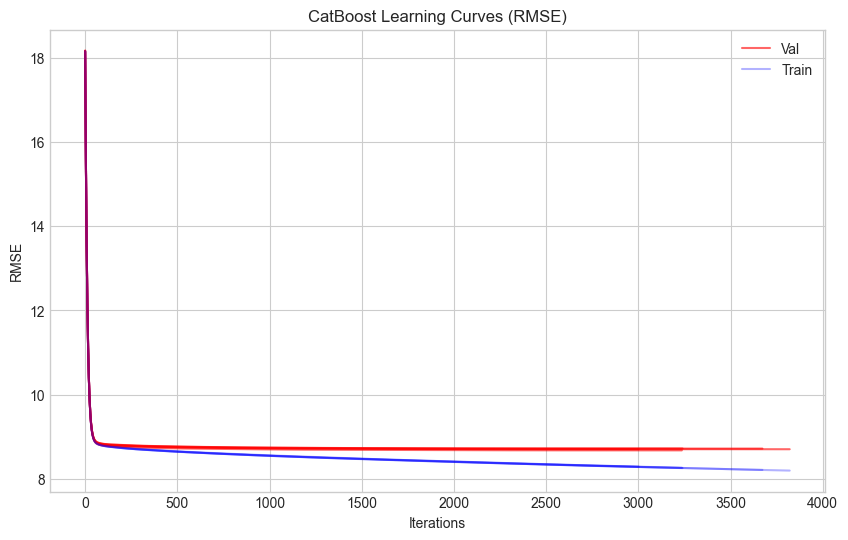

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='rmse')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features make sense (e.g., `study_hours` or `class_attendance` should likely be high).
* **Sanity Check:** If `id` or a random noise column appears in the top 5, there is a data leakage problem.
* **Engineering Check:** Look for the engineered features (e.g., `restoration_index`, `interaction_score`). If they appear near the top, the feature engineering added real value.

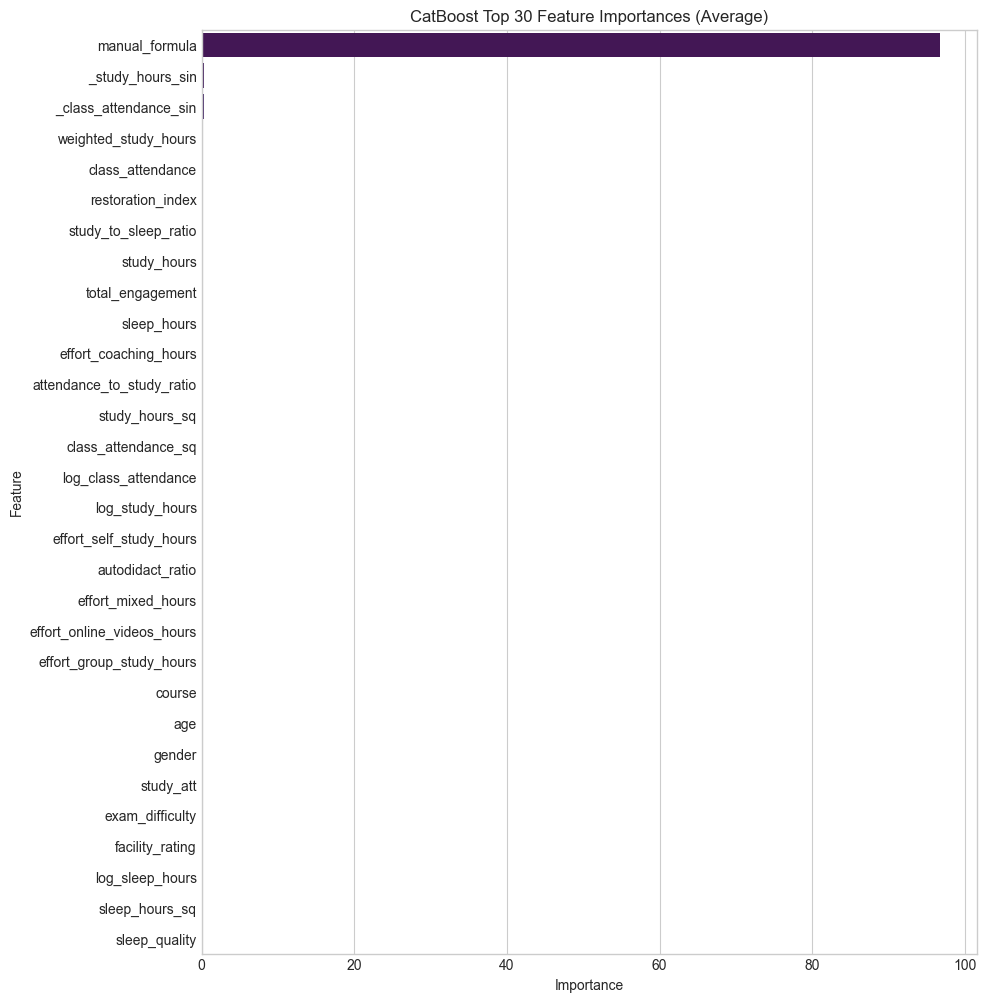

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

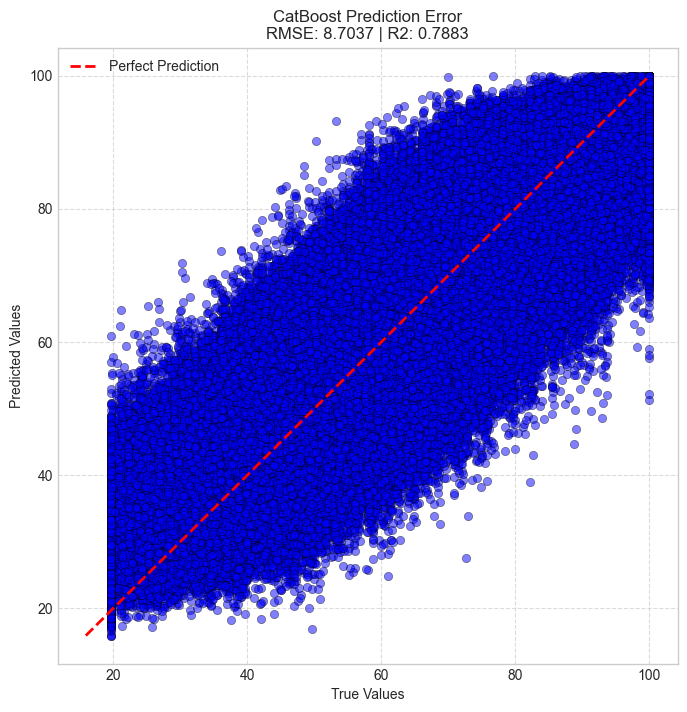

In [14]:
mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

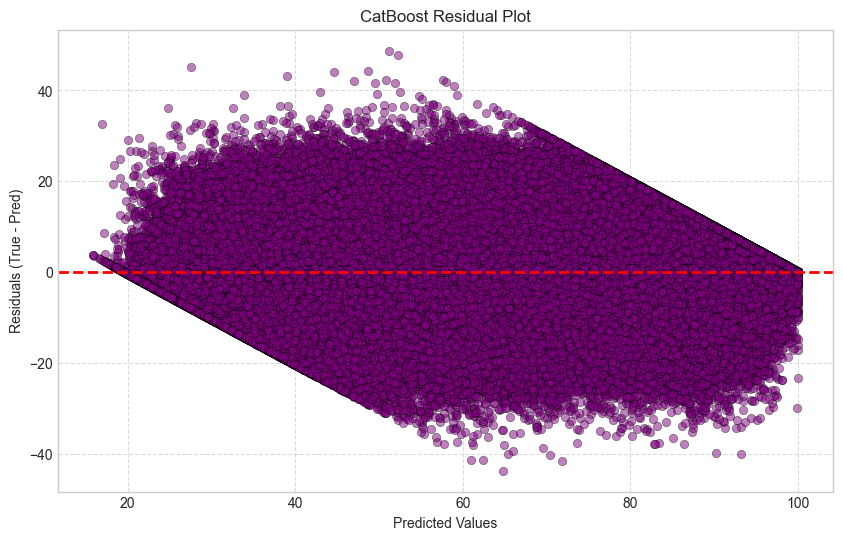

In [15]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [16]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.241
1  630001      70.276
2  630002      87.453
3  630003      55.819
4  630004      47.327
5  630005      71.758
6  630006      73.461
7  630007      58.386
8  630008      78.169
9  630009      90.216


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_cb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/cb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_cb': test_preds})
test_pred_df.to_csv(f'{output_dir}/cb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/cb_oof_preds.csv, {output_dir}/cb_test_preds.csv')

Saved for Blending: predictions/cb_oof_preds.csv, predictions/cb_test_preds.csv
